# L = 4 — NQS vs ED
Relative-error validation. $h_z \\in [0, 0.30]$ (ED available).

In [35]:
import json, re
from pathlib import Path
import numpy as np
import matplotlib.pyplot as plt

plt.rcParams.update({"figure.dpi": 120, "font.size": 11, "axes.spines.top": False,
                     "axes.spines.right": False, "axes.grid": True, "grid.alpha": 0.3})
NQS, ED = Path("../results/nqs"), Path("../results/ed")
FIG = Path("../figures"); FIG.mkdir(exist_ok=True)          # high-res outputs land here

In [36]:
nqs = lambda hz: np.array([complex(x).real for x in
        json.load(open(NQS / f"G-equiv_1_L4_hx0.00_hz{hz:.2f}.json"))["energy"]])
edE0 = lambda hz: json.load(open(ED / f"ed_L4_hx0.00_hz{hz:.2f}.json"))["E0"]
hzs = [0.0, 0.05, 0.10, 0.15, 0.20, 0.25, 0.30]

In [37]:
# --- knobs ---
HZ_SEL = hzs        # runs to plot; e.g. [0.0, 0.10, 0.30]
ELIM   = None       # E-axis y-limits, e.g. (-25.6, -24.8); None = auto

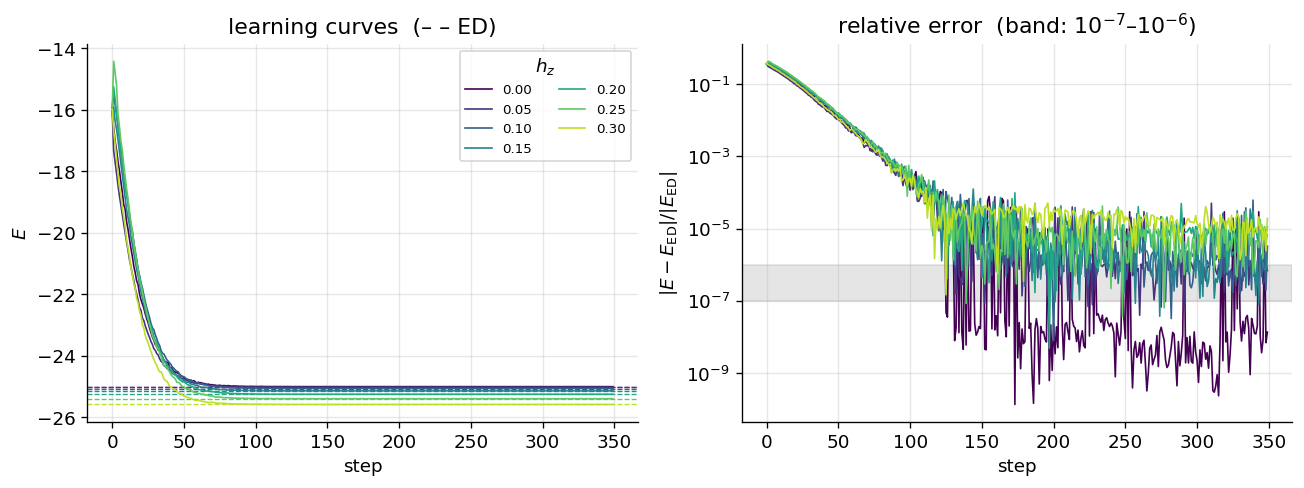

In [38]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(11, 4.2))
for c, hz in zip(plt.cm.viridis(np.linspace(0, 0.9, len(HZ_SEL))), HZ_SEL):
    E = nqs(hz); s = np.arange(len(E)); E0 = edE0(hz)
    ax1.plot(s, E, color=c, lw=1, label=f"{hz:.2f}")
    ax1.axhline(E0, color=c, ls="--", lw=0.8)
    ax2.plot(s, np.abs(E - E0) / abs(E0), color=c, lw=1)
ax1.set(xlabel="step", ylabel="$E$", title="learning curves  (– – ED)")
if ELIM: ax1.set_ylim(*ELIM)
ax1.legend(title="$h_z$", ncol=2, fontsize=8)
ax2.axhspan(1e-7, 1e-6, color="grey", alpha=0.2)
ax2.set(xlabel="step", ylabel=r"$|E-E_{\mathrm{ED}}|/|E_{\mathrm{ED}}|$", yscale="log",
        title=r"relative error  (band: $10^{-7}$–$10^{-6}$)")
fig.tight_layout()
# fig.savefig(FIG / "L4_vs_ED.png", dpi=300, bbox_inches="tight")